# Linear regression of offshore waves from atmospheric PCs

Use the full shared record of buoy **46050 bulk observations (1991–2025 by default)** and the daily atmospheric PCs saved by `PCA_mslp.ipynb`.

- **MSL:** all retained pressure-only PCs.
- **MSL + gradient:** all retained pressure + spatial-gradient PCs.
- Targets: daily mean **Hs** and a clearly labeled **energy index Hs² × Tp**.

Use the earlier years for fitting and the last 10% of calendar years for evaluation, with a seven-day gap. Compare both models on the same days, and repeat with equal numbers of PCs. Finally save separate estimators refitted on all shared dates for subsequent use.

This is a same-day regression, not a lead-time forecast. The fixed PCA bases were fitted on 1979–2025, including test-period atmospheric data. Wave targets are held out for evaluation, but a fully independent forecasting pipeline would also refit PCA on training-period fields. No spectra are downloaded or reconstructed in this notebook.

The atmospheric models use **20–60°N, 165–105°W**, cropped and masked to exclude land before PCA fitting.


In [1]:
from pathlib import Path
import logging
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
from bluemath_tk.core.io import load_model

logging.getLogger("PCA").setLevel(logging.ERROR)
repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / "toolkit" / "data" / "outputs").is_dir())
pca_paths = {
    "MSL": repo_root / "toolkit/datamining/outputs/pca_msl_north_pacific_20N-60N_165W-105W_1979-2025_2deg_ocean.pkl",
    "MSL + gradient": repo_root / "toolkit/datamining/outputs/pca_msl_gradient_north_pacific_20N-60N_165W-105W_1979-2025_2deg_ocean.pkl",
}
output_path = repo_root / "toolkit/regression/outputs"
output_path.mkdir(parents=True, exist_ok=True)
colors = {"MSL": "#29ABAF", "MSL + gradient": "#DF826B"}
targets = ["hs", "energy_flux_proxy"]
labels = {"hs": "Daily mean Hs (m)", "energy_flux_proxy": "Daily mean Hs² × Tp (m² s)"}
TEST_FRACTION_YEARS = 0.10
GAP_DAYS = 7
MIN_SAMPLES_PER_DAY = 1  # Use every day with at least one valid bulk observation.


## Download buoy bulk parameters

Download **bulk parameters only** for buoy **46050 (Stonewall Bank, Oregon)**. Choose one year, a period, or all available years. The default is **1991–2025**. This section does not download directional coefficients or reconstruct wave spectra.

The raw merged CSV is stored in `toolkit/regression/outputs/noaa_data/buoy_data/46050/`, separate from the one downloaded by `NDBC_buoy_data.ipynb`. A local CSV that already covers the selected years is reused. Set `REFRESH_BULK=True` to redownload the selected years. The download result reports any unavailable or failed years.

In [2]:
import sys
from bluemath_tk.downloaders.noaa.noaa_downloader import NOAADownloader

# Import the course helpers regardless of the notebook's working directory.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from toolkit.data.utils.ndbc_data import load_buoy_bulk, prepare_daily_bulk, daily_wave_targets
from toolkit.data.utils.ndbc_plotting import plot_daily_bulk

noaa_downloader = NOAADownloader(
    base_path_to_download=str(output_path / "noaa_data"),
    debug=True, check=False,
)
buoy_id = "46050"  # Stonewall Bank, Oregon
# "single": single_year; "period": inclusive start/end; "all": all available years.
download_mode = "period"
single_year = 2020
start_year = 1991
end_year = 2025


In [3]:
REFRESH_BULK = False
buoy_df, years, bulk_csv = load_buoy_bulk(
    noaa_downloader, buoy_id, download_mode=download_mode,
    single_year=single_year, start_year=start_year, end_year=end_year,
    refresh=REFRESH_BULK,
)

Buoy 46050: 35 year(s) selected -> [1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Reusing /workspaces/BlueMath_Course_Corvallis/toolkit/regression/outputs/noaa_data/buoy_data/46050/buoy_46050_bulk_parameters.csv; set refresh=True to download again.
Buoy 46050: 644,062 bulk records, 1991-11-16 18:00:00 to 2025-12-31 23:50:00


In [4]:
bulk_wave_observations, bulk_wave_parameters = prepare_daily_bulk(buoy_df)
display(bulk_wave_parameters)

# Save the cleaned daily bulk parameters for reuse in other notebooks
# (toolkit/data is where the MUSCLE emulator, 05_Emulator.ipynb, loads them from).
for bulk_parameters_file in [output_path / f"buoy_{buoy_id}_bulk_wave_parameters_daily.csv",
                             repo_root / f"toolkit/data/buoy_{buoy_id}_bulk_wave_parameters_daily.csv"]:
    bulk_wave_parameters.to_csv(bulk_parameters_file, index_label="time")
    print(f"Saved daily bulk wave parameters: {bulk_parameters_file}")


,WVHT,DPD,APD,MWD
datetime,,,,
1991-11-16,6.760000,10.540000,8.540000,201.599978
1991-11-17,6.670000,13.400000,9.685000,259.141796
1991-11-18,4.909524,14.357143,9.657143,270.187794
1991-11-19,5.322222,14.766667,9.077778,275.360136
1991-11-20,5.441667,12.041667,9.070833,244.907473
...,...,...,...,...
2025-12-27,3.303958,10.405625,7.369792,299.665177
2025-12-28,2.278958,10.388542,7.179167,315.667312
2025-12-29,1.477292,10.524792,6.372708,305.165969


Saved daily bulk wave parameters: /workspaces/BlueMath_Course_Corvallis/toolkit/regression/outputs/buoy_46050_bulk_wave_parameters_daily.csv


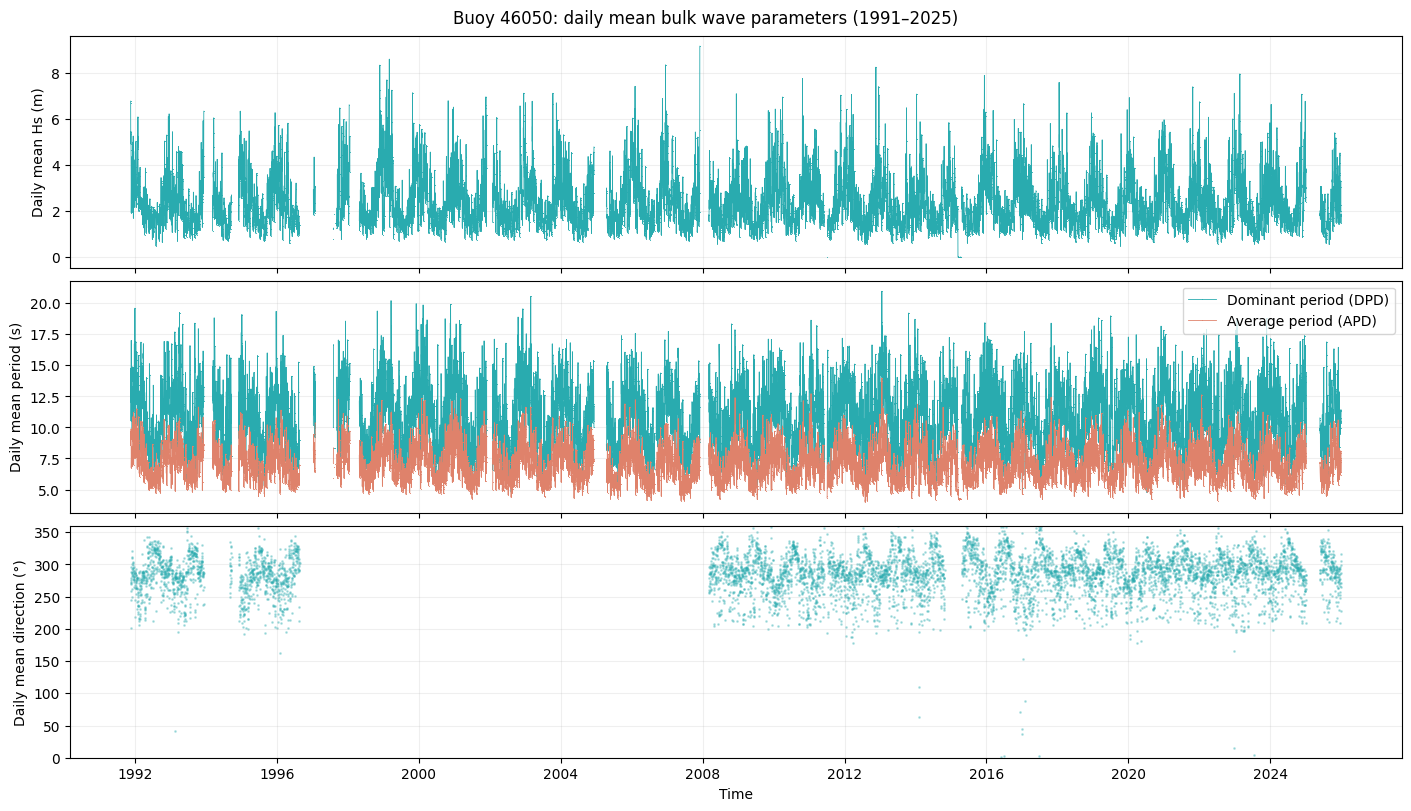

In [5]:
plot_daily_bulk(bulk_wave_parameters, buoy_id, years);


## 1. Load the two fitted PCA models

Use their stored daily scores, without refitting PCA. The pressure-only model retains 95% of pressure variance; the combined model retains 20 components. Their explained-variance percentages refer to different input feature sets and cannot be compared as wave-regression skill.
Load the ocean-only regional models (`_ocean.pkl`) fitted on 20–60°N, 165–105°W.


In [6]:
pca_models = {name: load_model(str(path)) for name, path in pca_paths.items()}
pc_frames = {}
model_summary = []
for name, model in pca_models.items():
    if getattr(model, "region_id", None) != "north_pacific_20N-60N_165W-105W":
        raise ValueError(f"{name}: expected the newly fitted North Pacific model.")
    scores = model.pcs.PCs.transpose("time", "n_component")
    frame = pd.DataFrame(scores.values.astype(np.float64), index=pd.DatetimeIndex(scores.time.values),
                         columns=[f"PC{i + 1}" for i in range(scores.sizes["n_component"])])
    if frame.index.has_duplicates or not frame.index.equals(frame.index.normalize()):
        raise ValueError(f"{name}: expected unique daily PCs at midnight.")
    pc_frames[name] = frame.sort_index()
    model_summary.append({"model": name, "PCs": frame.shape[1],
                          "PCA variance retained": float(model.cumulative_explained_variance_ratio[-1]),
                          "start": frame.index.min(), "end": frame.index.max()})
display(pd.DataFrame(model_summary).set_index("model"))

,PCs,PCA variance retained,start,end
model,,,,
MSL,10,0.955216,1979-01-01,2025-12-31
MSL + gradient,20,0.864053,1979-01-01,2025-12-31


## 2. Daily targets from the full bulk record

Use **Hs = WVHT** and **Tp = DPD** from the buoy bulk observations. The energy target is simply:

$$I = H_s^2 T_p \quad [\mathrm{m^2\,s}].$$

There is no physical prefactor or conversion to kW/m: this is an energy index. Calculate `WVHT**2 * DPD` for each observation, then average daily. Missing-value codes are removed before averaging. Keep days with at least `MIN_SAMPLES_PER_DAY` valid observations and preserve gaps; counts are saved alongside the targets.


In [7]:
wave_daily, target_counts, daily = daily_wave_targets(
    bulk_wave_observations, bulk_csv, buoy_id,
    min_samples_per_day=MIN_SAMPLES_PER_DAY,
)
print(f"Available daily wave record: {wave_daily.dropna().index.min().date()} to {wave_daily.dropna().index.max().date()}")
print(f"Valid paired days before PCA alignment: {len(wave_daily.dropna()):,}")
display(wave_daily.describe())


Available daily wave record: 1991-11-16 to 2025-12-31
Valid paired days before PCA alignment: 11,338


,hs,energy_flux_proxy
count,11352.000000,11338.000000
mean,2.369558,85.005045
std,1.136065,101.962903
min,0.010000,2.262875
25%,1.541667,21.997551
50%,2.092476,46.855488
75%,2.956474,107.498330
max,9.141667,1147.405004


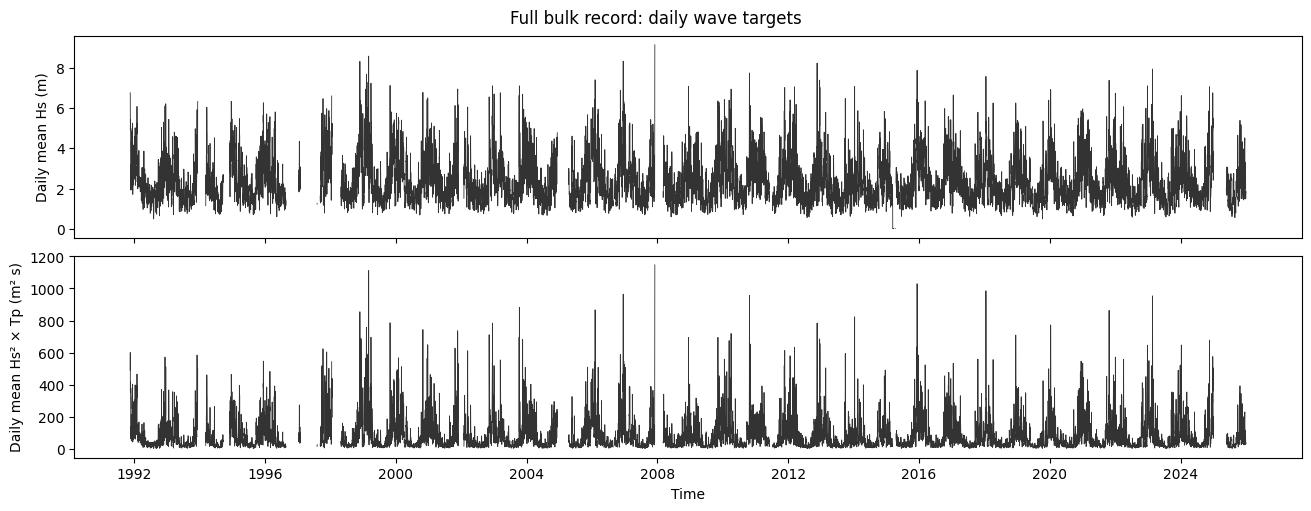

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True, layout="constrained")
for ax, target in zip(axes, targets):
    ax.plot(wave_daily.index, wave_daily[target], color="0.2", linewidth=0.6)
    ax.set_ylabel(labels[target])
axes[-1].set_xlabel("Time")
fig.suptitle("Full bulk record: daily wave targets");

## 3. Align the entire record and reserve the latest years for evaluation

Keep dates with valid targets and finite PCs in both models. Reserve the last 10% of represented calendar years for testing (2022–2025 for the default record), with a seven-day gap before the test block. All earlier shared dates train the regressions. No random split or test-based PC selection is used.

Both models and the matched-PC comparison use exactly the same dates. The train-mean predictor is a simple reference. All shared dates are used again in the final full-record refit, after the held-out comparison has been calculated.


In [9]:
common = wave_daily.dropna().index
for frame in pc_frames.values():
    common = common.intersection(frame.index[np.isfinite(frame).all(axis=1)])
common = common.sort_values()
y = wave_daily.loc[common, targets]
X = {name: frame.loc[common] for name, frame in pc_frames.items()}
available_years_for_fit = np.sort(common.year.unique())
if len(available_years_for_fit) < 2:
    raise ValueError("The full-record regression needs at least two years of overlapping data.")
n_test_years = min(len(available_years_for_fit) - 1,
                   max(1, int(np.ceil(len(available_years_for_fit) * TEST_FRACTION_YEARS))))
TEST_START = pd.Timestamp(year=int(available_years_for_fit[-n_test_years]), month=1, day=1)
print(f"Shared record: {common.min().date()} to {common.max().date()} ({len(common):,} valid days)")
train_mask = common < TEST_START - pd.Timedelta(days=GAP_DAYS)
test_mask = common >= TEST_START
gap_mask = ~(train_mask | test_mask)
if train_mask.sum() <= max(frame.shape[1] for frame in X.values()) + 1 or test_mask.sum() < 30:
    raise ValueError("Insufficient common dates for these predictor counts and temporal split.")
assert not np.any(train_mask & test_mask)
assert common[train_mask].max() < common[test_mask].min() - pd.Timedelta(days=GAP_DAYS)
split = pd.Series(np.where(train_mask, "train", np.where(test_mask, "test", "gap")), index=common, name="split")
display(pd.DataFrame([
    {"split": name, "days": int(mask.sum()), "start": common[mask].min(), "end": common[mask].max()}
    for name, mask in [("train", train_mask), ("gap", gap_mask), ("test", test_mask)]
]))

Shared record: 1991-11-16 to 2025-12-31 (11,338 valid days)


,split,days,start,end
0,train,10010,1991-11-16,2021-12-24
1,gap,7,2021-12-25,2021-12-31
2,test,1321,2022-01-01,2025-12-31


## 4. Fit the two linear regressions

For each target, fit an intercept and one coefficient per PC:

$$\widehat{y}(t)=\beta_0+\sum_{j=1}^{K}\beta_j\,PC_j(t).$$

`LinearRegression` with two output columns fits these two ordinary least-squares regressions independently. It does not force a physical relationship between predicted Hs and predicted flux. Use all retained PCs from each saved model for the main comparison. Targets remain in physical units, without logarithms or clipping; negative predictions are counted explicitly.

In [10]:
regressions, predictions, coefficient_tables = {}, {}, []
for name, frame in X.items():
    regression = LinearRegression()
    regression.fit(frame.loc[train_mask], y.loc[train_mask])
    regressions[name] = regression
    predictions[name] = pd.DataFrame(regression.predict(frame), index=common, columns=targets)
    for i, target in enumerate(targets):
        coefficients = pd.Series(regression.coef_[i], index=frame.columns)
        coefficients.loc["intercept"] = regression.intercept_[i]
        coefficient_tables.append(coefficients.rename("coefficient").rename_axis("term").reset_index()
                                  .assign(model=name, target=target))
baseline = pd.DataFrame(np.tile(y.loc[train_mask].mean().values, (len(y), 1)),
                        index=common, columns=targets)
coefficients = pd.concat(coefficient_tables, ignore_index=True)

## 5. Compare performance on the same unseen wave dates

Report training and test scores separately. Lower RMSE and MAE are better; bias is prediction minus observation. Test R² can be negative. `skill_vs_train_mean` is 1 − model MSE / baseline MSE, using the training-mean baseline on the same evaluated dates. Correlation alone does not measure amplitude or bias.

In [11]:
def evaluate(observed, predicted):
    residual = predicted - observed
    correlation = (float(np.corrcoef(observed, predicted)[0, 1])
                   if np.std(predicted) > 1e-12 and np.std(observed) > 1e-12 else np.nan)
    return {"RMSE": float(np.sqrt(mean_squared_error(observed, predicted))),
            "MAE": float(mean_absolute_error(observed, predicted)),
            "bias": float(np.mean(residual)), "R2": float(r2_score(observed, predicted)),
            "correlation": correlation, "negative_predictions": int((predicted < 0).sum())}

rows = []
for name, prediction in {**predictions, "Train mean": baseline}.items():
    for subset, mask in [("train", train_mask), ("test", test_mask)]:
        for target in targets:
            metrics = evaluate(y.loc[mask, target], prediction.loc[mask, target])
            baseline_mse = mean_squared_error(y.loc[mask, target], baseline.loc[mask, target])
            metrics["skill_vs_train_mean"] = 1 - metrics["RMSE"]**2 / baseline_mse
            rows.append({"model": name, "target": target, "split": subset,
                         "n_days": int(mask.sum()), "n_pcs": X[name].shape[1] if name in X else 0, **metrics})
metrics = pd.DataFrame(rows)
display(metrics.set_index(["split", "target", "model"]).round(3))

n_days  n_pcs     RMSE     MAE   bias  \
split target            model                                                   
train hs                MSL              10010     10    0.894   0.699  0.000   
      energy_flux_proxy MSL              10010     10   83.051  55.223 -0.000   
test  hs                MSL               1321     10    0.907   0.726  0.079   
      energy_flux_proxy MSL               1321     10   81.487  56.219  4.758   
train hs                MSL + gradient   10010     20    0.834   0.642  0.000   
      energy_flux_proxy MSL + gradient   10010     20   79.364  51.060  0.000   
test  hs                MSL + gradient    1321     20    0.837   0.654  0.043   
      energy_flux_proxy MSL + gradient    1321     20   77.678  51.276  1.852   
train hs                Train mean       10010      0    1.134   0.883  0.000   
      energy_flux_proxy Train mean       10010      0  102.344  69.457  0.000   
test  hs                Train mean        1321      0    1.129   0.902  0.055   
      energy_flux_proxy Train mean        1321      0   98.468  69.017  3.030   

                                           R2  correlation  \
split target            model                                
train hs                MSL             0.378        0.615   
      energy_flux_proxy MSL             0.341        0.584   
test  hs                MSL             0.353        0.599   
      energy_flux_proxy MSL             0.315        0.564   
train hs                MSL + gradient  0.459        0.678   
      energy_flux_proxy MSL + gradient  0.399        0.631   
test  hs                MSL + gradient  0.450        0.672   
      energy_flux_proxy MSL + gradient  0.377        0.616   
train hs                Train mean      0.000          NaN   
      energy_flux_proxy Train mean      0.000          NaN   
test  hs                Train mean     -0.002          NaN   
      energy_flux_proxy Train mean     -0.001          NaN   

                                        negative_predictions  \
split target            model                                  
train hs                MSL                                0   
      energy_flux_proxy MSL                              416   
test  hs                MSL                                0   
      energy_flux_proxy MSL                               42   
train hs                MSL + gradient                     0   
      energy_flux_proxy MSL + gradient                   292   
test  hs                MSL + gradient                     0   
      energy_flux_proxy MSL + gradient                    49   
train hs                Train mean                         0   
      energy_flux_proxy Train mean                         0   
test  hs                Train mean                         0   
      energy_flux_proxy Train mean                         0   

                                        skill_vs_train_mean  
split target            model                                
train hs                MSL                           0.378  
      energy_flux_proxy MSL                           0.341  
test  hs                MSL                           0.355  
      energy_flux_proxy MSL                           0.315  
train hs                MSL + gradient                0.459  
      energy_flux_proxy MSL + gradient                0.399  
test  hs                MSL + gradient                0.451  
      energy_flux_proxy MSL + gradient                0.378  
train hs                Train mean                   -0.000  
      energy_flux_proxy Train mean                    0.000  
test  hs                Train mean                    0.000  
      energy_flux_proxy Train mean                    0.000

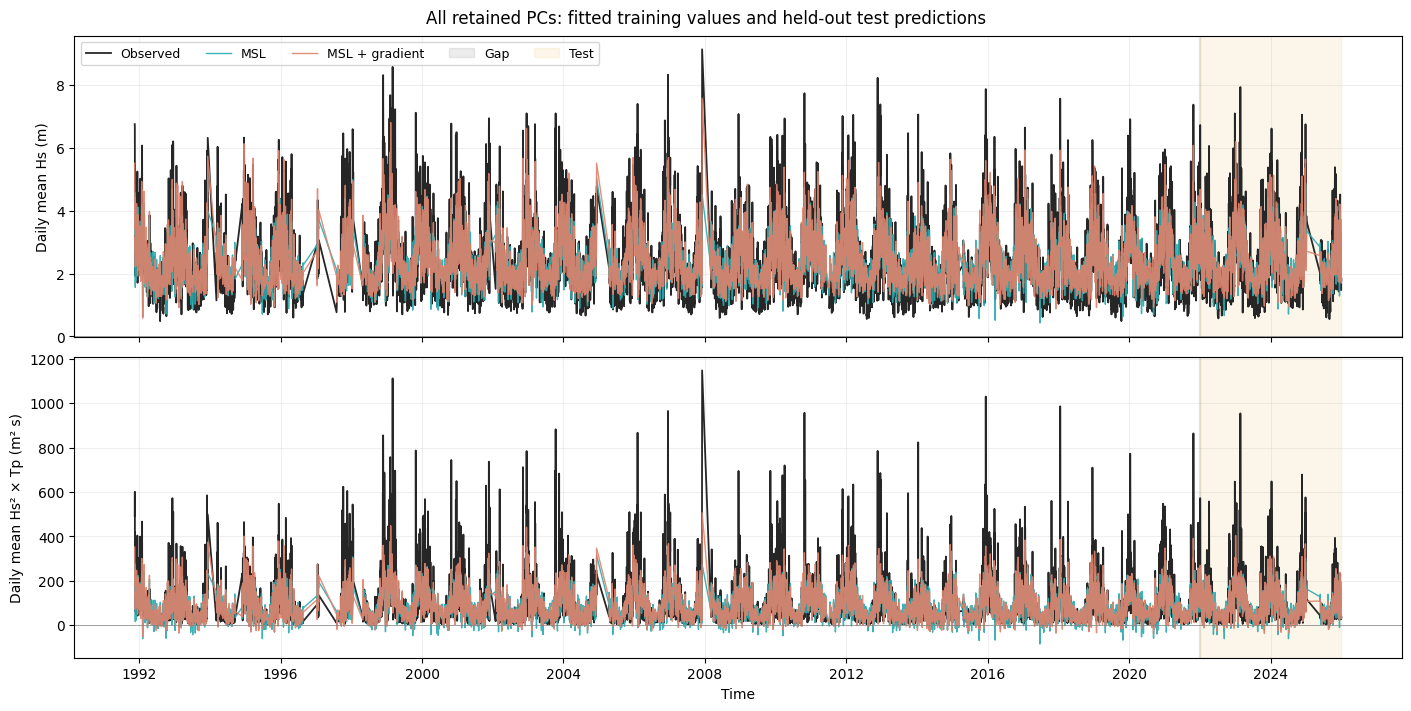

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, layout="constrained")
for ax, target in zip(axes, targets):
    ax.plot(common, y[target], color="0.15", linewidth=1.3, label="Observed")
    for name, prediction in predictions.items():
        ax.plot(common, prediction[target], color=colors[name], linewidth=1, alpha=0.9, label=name)
    ax.axvspan(TEST_START - pd.Timedelta(days=GAP_DAYS), TEST_START, color="0.5", alpha=0.15, label="Gap")
    ax.axvspan(TEST_START, common.max(), color="#E5C56C", alpha=0.15, label="Test")
    ax.axhline(0, color="0.5", linewidth=0.5)
    ax.set_ylabel(labels[target])
    ax.grid(alpha=0.2)
axes[0].legend(ncol=5, fontsize=9)
axes[1].set_xlabel("Time")
fig.suptitle("All retained PCs: fitted training values and held-out test predictions");

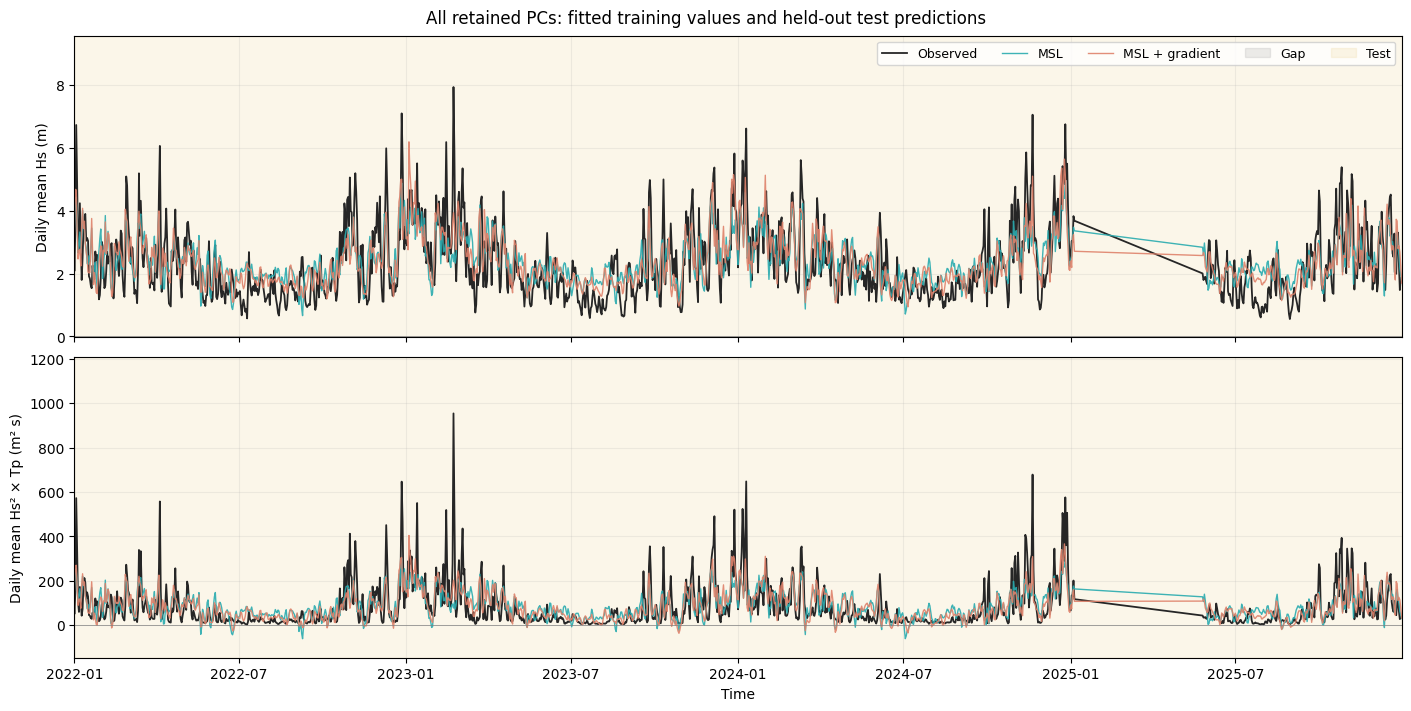

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, layout="constrained")
for ax, target in zip(axes, targets):
    ax.plot(common, y[target], color="0.15", linewidth=1.3, label="Observed")
    for name, prediction in predictions.items():
        ax.plot(common, prediction[target], color=colors[name], linewidth=1, alpha=0.9, label=name)
    ax.axvspan(TEST_START - pd.Timedelta(days=GAP_DAYS), TEST_START, color="0.5", alpha=0.15, label="Gap")
    ax.axvspan(TEST_START, common.max(), color="#E5C56C", alpha=0.15, label="Test")
    ax.axhline(0, color="0.5", linewidth=0.5)
    ax.set_ylabel(labels[target])
    ax.grid(alpha=0.2)
axes[0].legend(ncol=5, fontsize=9)
axes[1].set_xlabel("Time")
axes[0].set_xlim(TEST_START, common.max())
fig.suptitle("All retained PCs: fitted training values and held-out test predictions");

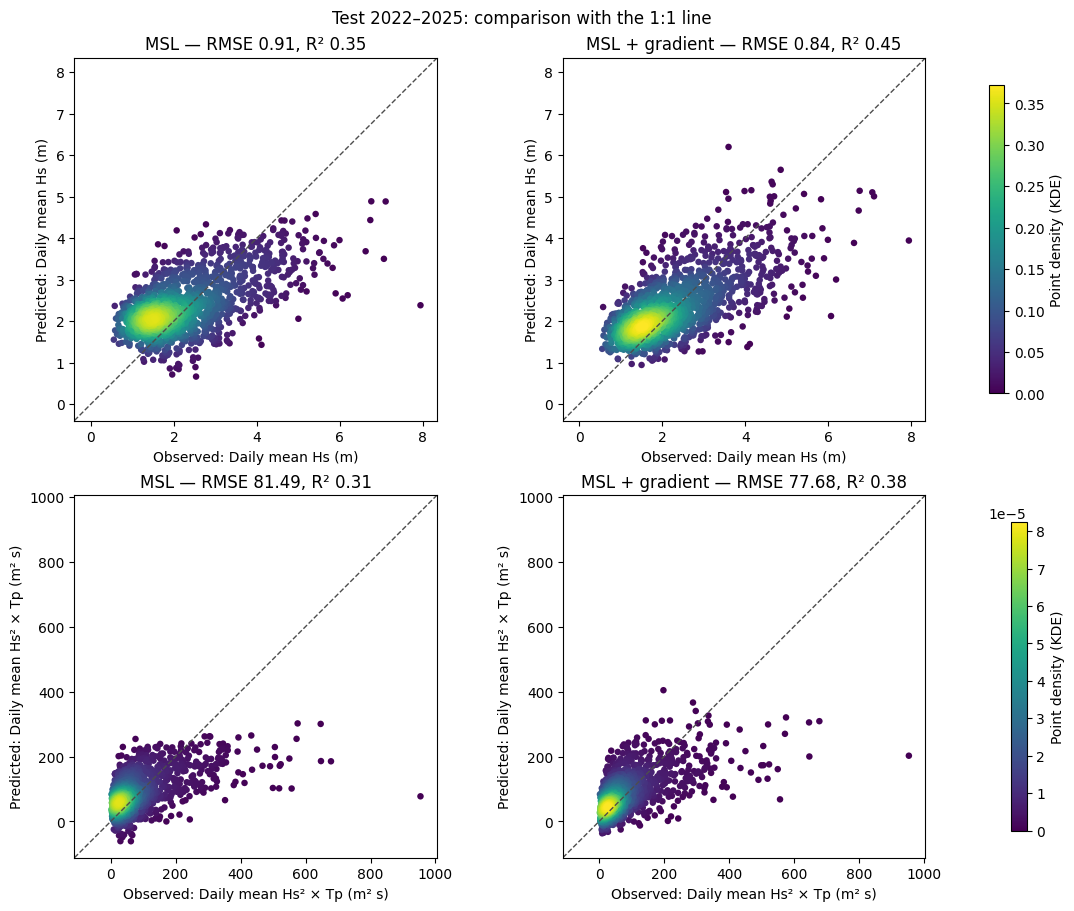

In [14]:
from scipy.stats import gaussian_kde
from matplotlib.colors import Normalize

fig, axes = plt.subplots(2, 2, figsize=(11, 9), layout="constrained")
for i, target in enumerate(targets):
    observed = y.loc[test_mask, target]
    combined_values = np.concatenate([observed.values] + [p.loc[test_mask, target].values for p in predictions.values()])
    low, high = min(0, combined_values.min()), combined_values.max()
    margin = 0.05 * (high - low)
    limits = (low - margin, high + margin)
    # Estimate a 2D probability density for each model in the target's units.
    density_panels = []
    for name, prediction in predictions.items():
        x_values = observed.to_numpy()
        y_values = prediction.loc[test_mask, target].to_numpy()
        xy = np.vstack([x_values, y_values])
        density = gaussian_kde(xy)(xy)
        density_panels.append((name, x_values, y_values, density))
    norm = Normalize(vmin=0, vmax=max(panel[3].max() for panel in density_panels))
    for j, (name, x_values, y_values, density) in enumerate(density_panels):
        ax = axes[i, j]
        # Draw denser points last so they remain visible.
        order = np.argsort(density)
        scatter = ax.scatter(x_values[order], y_values[order], c=density[order],
                             cmap="viridis", norm=norm, s=22, edgecolors="none", rasterized=True)
        ax.plot(limits, limits, color="0.3", linestyle="--", linewidth=1)
        score = metrics.query("model == @name and target == @target and split == 'test'").iloc[0]
        ax.set(xlim=limits, ylim=limits, xlabel=f"Observed: {labels[target]}",
               ylabel=f"Predicted: {labels[target]}",
               title=f"{name} — RMSE {score.RMSE:.2f}, R² {score.R2:.2f}")
        ax.set_aspect("equal", adjustable="box")
    fig.colorbar(scatter, ax=axes[i, :], shrink=0.85, label="Point density (KDE)")
fig.suptitle(f"Test {common[test_mask].min().year}–{common[test_mask].max().year}: comparison with the 1:1 line");

## 6. Control for the number of PCs

The main comparison uses the two saved models as they are, so it changes both the predictors and their count. Repeat the regressions using the **same number of leading PCs in both models**, using the smaller available count. Use exactly the same targets and split, without choosing the count from test performance. This control helps assess the gradient at matched model size; it does not guarantee that this count is optimal.

,,n_pcs,RMSE,MAE,bias,R2,correlation,negative_predictions
target,model,,,,,,,
hs,MSL,10,0.907,0.726,0.079,0.353,0.599,0
energy_flux_proxy,MSL,10,81.487,56.219,4.758,0.315,0.564,42
hs,MSL + gradient,10,0.870,0.686,0.051,0.404,0.638,0
energy_flux_proxy,MSL + gradient,10,80.144,53.715,2.454,0.337,0.583,29


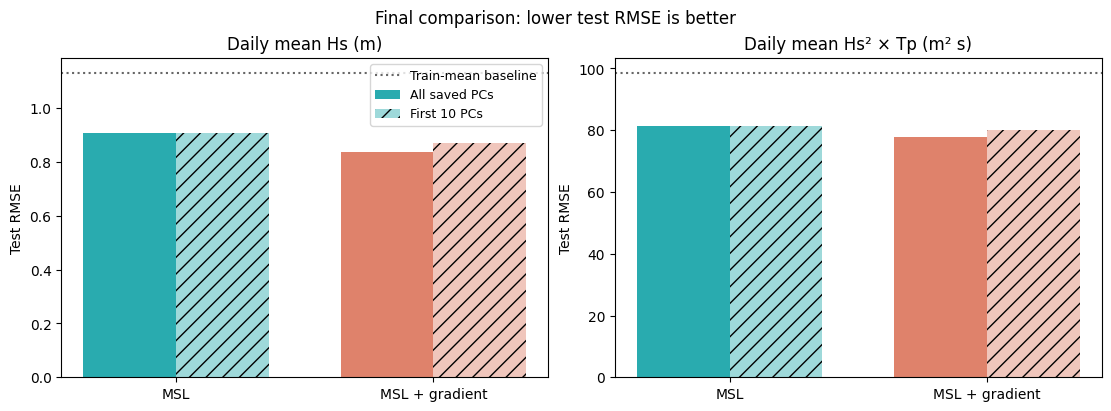

In [15]:
matched_count = min(frame.shape[1] for frame in X.values())
matched_regressions, matched_predictions, matched_rows = {}, {}, []
for name, frame in X.items():
    predictors = frame.iloc[:, :matched_count]
    regression = LinearRegression().fit(predictors.loc[train_mask], y.loc[train_mask])
    matched_regressions[name] = regression
    prediction = pd.DataFrame(regression.predict(predictors), index=common, columns=targets)
    matched_predictions[name] = prediction
    for target in targets:
        matched_rows.append({"model": name, "target": target, "n_pcs": matched_count,
                             **evaluate(y.loc[test_mask, target], prediction.loc[test_mask, target])})
matched_metrics = pd.DataFrame(matched_rows)
display(matched_metrics.set_index(["target", "model"]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, target in zip(axes, targets):
    positions = np.arange(len(X))
    main_rmse = [float(metrics.query("model == @name and target == @target and split == 'test'").RMSE.iloc[0]) for name in X]
    control_rmse = [float(matched_metrics.query("model == @name and target == @target").RMSE.iloc[0]) for name in X]
    ax.bar(positions - 0.18, main_rmse, width=0.36, color=[colors[name] for name in X], label="All saved PCs")
    ax.bar(positions + 0.18, control_rmse, width=0.36, color=[colors[name] for name in X],
           alpha=0.45, hatch="//", label=f"First {matched_count} PCs")
    baseline_rmse = float(metrics.query("model == 'Train mean' and target == @target and split == 'test'").RMSE.iloc[0])
    ax.axhline(baseline_rmse, color="0.4", linestyle=":", label="Train-mean baseline")
    ax.set(xticks=positions, xticklabels=list(X), ylabel="Test RMSE", title=labels[target])
axes[0].legend(fontsize=9)
fig.suptitle("Final comparison: lower test RMSE is better");

In [16]:
for target in targets:
    main = metrics.query("target == @target and split == 'test' and model != 'Train mean'")
    control = matched_metrics.query("target == @target")
    best_main = main.loc[main.RMSE.idxmin()]
    best_control = control.loc[control.RMSE.idxmin()]
    print(f"{labels[target]}: lower test RMSE with all PCs: {best_main.model} ({best_main.RMSE:.3f}); "
          f"with {matched_count} PCs each: {best_control.model} ({best_control.RMSE:.3f}).")
print(f"Evaluation covers {common[test_mask].min().date()} to {common[test_mask].max().date()}; PCA bases remain fixed over 1979–2025.")

Daily mean Hs (m): lower test RMSE with all PCs: MSL + gradient (0.837); with 10 PCs each: MSL + gradient (0.870).
Daily mean Hs² × Tp (m² s): lower test RMSE with all PCs: MSL + gradient (77.678); with 10 PCs each: MSL + gradient (80.144).
Evaluation covers 2022-01-01 to 2025-12-31; PCA bases remain fixed over 1979–2025.


## 7. Refit on all shared dates and save

After evaluation, fit final estimators using **all available shared days**. Save both the evaluation estimators and full-record estimators in each bundle, with explicit keys. Held-out scores and comparison plots always come from the evaluation estimators, never from the full-record refit. Targets, metadata and filenames identify the bulk source and Hs² × Tp energy index.


In [17]:
full_record_regressions = {name: LinearRegression().fit(frame, y) for name, frame in X.items()}
full_record_matched = {name: LinearRegression().fit(frame.iloc[:, :matched_count], y) for name, frame in X.items()}
metadata = {
    "wave_source": str(bulk_csv), "buoy_id": buoy_id,
    "pca_region": pca_models["MSL"].region_bounds,
    "record_start": str(common.min().date()), "record_end": str(common.max().date()),
    "n_shared_days": len(common),
    "test_start": str(TEST_START.date()), "test_end": str(common[test_mask].max().date()),
    "gap_days": GAP_DAYS, "train_start": str(common[train_mask].min().date()),
    "train_end": str(common[train_mask].max().date()), "min_samples_per_day": MIN_SAMPLES_PER_DAY,
    "flux_method": "WVHT**2 * DPD; calculate per observation before daily averaging",
    "flux_limitation": "Hs squared times Tp is an energy index in m2 s, without a physical prefactor",
    "pca_note": "Fixed PCA bases fitted on 1979–2025; same-day regression, not a strict forecast evaluation",
}
for name, slug in [("MSL", "msl"), ("MSL + gradient", "msl_gradient")]:
    bundle = {
        "evaluation_regression": regressions[name], "evaluation_matched_regression": matched_regressions[name],
        "full_record_regression": full_record_regressions[name], "full_record_matched_regression": full_record_matched[name],
        "targets": targets, "pc_columns": list(X[name].columns),
        "matched_pc_columns": list(X[name].columns[:matched_count]),
        "pca_path": str(pca_paths[name]), "metadata": metadata,
    }
    model_file = output_path / f"waves_bulk_north_pacific_linear_{slug}.joblib"
    temporary = model_file.with_suffix(".tmp.joblib")
    joblib.dump(bundle, temporary)
    temporary.replace(model_file)
    loaded = joblib.load(model_file)
    np.testing.assert_allclose(loaded["evaluation_regression"].predict(X[name].loc[test_mask]),
                               predictions[name].loc[test_mask].values, rtol=1e-7, atol=1e-8)
    np.testing.assert_allclose(loaded["full_record_regression"].predict(X[name]),
                               full_record_regressions[name].predict(X[name]), rtol=1e-7, atol=1e-8)

prediction_table = y.add_prefix("observed_").join(split)
for name, slug in [("MSL", "msl"), ("MSL + gradient", "msl_gradient")]:
    prediction_table = prediction_table.join(predictions[name].add_prefix(f"{slug}_"))
    prediction_table = prediction_table.join(matched_predictions[name].add_prefix(f"{slug}_matched_"))
prediction_table = prediction_table.join(baseline.add_prefix("baseline_"))
prediction_table.index.name = "time"
prediction_table.to_csv(output_path / "waves_bulk_north_pacific_linear_predictions.csv")
prediction_ds = xr.Dataset.from_dataframe(prediction_table)
prediction_ds.attrs.update(description="Bulk daily wave regression: evaluation estimator predictions",
                           energy_flux_proxy_units="m2 s", hs_units="m",
                           flux_limitation=metadata["flux_limitation"], pca_note=metadata["pca_note"])
prediction_ds.to_netcdf(output_path / "waves_bulk_north_pacific_linear_predictions.nc")
daily.to_netcdf(output_path / "waves_bulk_daily_targets.nc")
metrics.to_csv(output_path / "waves_bulk_north_pacific_linear_metrics.csv", index=False)
matched_metrics.to_csv(output_path / "waves_bulk_north_pacific_linear_matched_metrics.csv", index=False)
coefficients.to_csv(output_path / "waves_bulk_north_pacific_linear_coefficients.csv", index=False)
print(f"Saved full-record and evaluation regressions in {output_path}")
print(f"Final estimators use all {len(common):,} shared days ({common.min().date()}–{common.max().date()}).")


Saved full-record and evaluation regressions in /workspaces/BlueMath_Course_Corvallis/toolkit/regression/outputs
Final estimators use all 11,338 shared days (1991-11-16–2025-12-31).
